##Step 1: Data Ingestion and Initial Assessment
Loading the raw datasets to understand their structure and identify any immediate data quality issues. I am starting by checking the datatypes, looking for missing values, and verifying if there are any duplicate records in the users table to determine the cleaning strategy

In [3]:
import pandas as pd

# Load the raw user data
users = pd.read_csv('Social_Engine_Users.csv')

# Check column data types and total entries
print("Users Dataset Overview:")
users.info()

# Count any missing values across columns
print("\nMissing Values Count:")
print(users.isna().sum())

# Check for exact duplicate records
duplicates = users.duplicated().sum()
print(f"\nDuplicate records found: {duplicates}")

Users Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          1500 non-null   object
 1   location         1500 non-null   object
 2   language         1500 non-null   object
 3   account_created  1500 non-null   object
 4   follower_count   1500 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 58.7+ KB

Missing Values Count:
user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64

Duplicate records found: 0


# 1.2 Duplicate User ID Check

We check whether any user ID appears more than once, since each user should have a unique identifier.

In [7]:
# Check whether any user ID appears more than once
users["user_id"].duplicated().sum()

np.int64(0)

### 1.3 Date Format Validation

The account creation dates are checked to ensure that all values can be interpreted as valid dates.

In [8]:
# Convert account_created to datetime
users["account_created"] = pd.to_datetime(
    users["account_created"],
    errors="coerce"
)

# Count values that could not be converted
users["account_created"].isna().sum()

np.int64(0)

## 1.4 Consistency Check

We inspect categorical values to identify inconsistent representations, spelling variations, or unexpected categories that may affect analysis.

In [9]:
# Inspect unique values in the categorical columns
print("Unique locations:", users["location"].nunique())
print("Unique languages:", users["language"].nunique())

print("\nLanguages:")
print(users["language"].value_counts())

print("\nTop locations:")
print(users["location"].value_counts().head(20))

Unique locations: 33
Unique languages: 10

Languages:
language
zh    168
ja    156
hi    156
en    153
fr    150
es    146
ru    144
ar    143
pt    143
de    141
Name: count, dtype: int64

Top locations:
location
Shanghai, China               56
Barcelona, Spain              56
Los Angeles, USA              55
Munich, Germany               54
Dubai, UAE                    53
Mumbai, India                 53
Milan, Italy                  53
Melbourne, Australia          52
Beijing, China                51
Chicago, USA                  50
Osaka, Japan                  50
Houston, USA                  50
Rio de Janeiro, Brazil        49
Singapore                     49
New York, USA                 48
Johannesburg, South Africa    48
Toronto, Canada               45
London, UK                    45
Paris, France                 45
São Paulo, Brazil             44
Name: count, dtype: int64


In [10]:
print(users["location"].unique())

['Berlin, Germany' 'Munich, Germany' 'Dubai, UAE' 'Paris, France'
 'Los Angeles, USA' 'Mumbai, India' 'Rio de Janeiro, Brazil'
 'Mexico City, Mexico' 'Vancouver, Canada' 'London, UK' 'Houston, USA'
 'Manchester, UK' 'Seoul, South Korea' 'Johannesburg, South Africa'
 'São Paulo, Brazil' 'Osaka, Japan' 'Rome, Italy' 'Barcelona, Spain'
 'Shanghai, China' 'Lagos, Nigeria' 'Tokyo, Japan' 'New York, USA'
 'Beijing, China' 'Melbourne, Australia' 'Lyon, France' 'Madrid, Spain'
 'Milan, Italy' 'Chicago, USA' 'Singapore' 'Delhi, India'
 'Sydney, Australia' 'Cairo, Egypt' 'Toronto, Canada']


### 1.5 Follower Count Anomaly Check

The follower_count column was examined using descriptive statistics, including the minimum and maximum values, to identify unusually low or high follower counts and potential anomalies.

In [11]:
print(users["follower_count"].describe())
print("\nMinimum:", users["follower_count"].min())
print("Maximum:", users["follower_count"].max())

count     1500.000000
mean     24964.019333
std      14185.477457
min        109.000000
25%      12771.750000
50%      24741.500000
75%      37097.250000
max      49944.000000
Name: follower_count, dtype: float64

Minimum: 109
Maximum: 49944


In [12]:
print("Missing values after cleaning:")
print(users.isnull().sum())

print("\nDuplicate rows after cleaning:", users.duplicated().sum())
print("Duplicate user IDs after cleaning:", users["user_id"].duplicated().sum())

Missing values after cleaning:
user_id            0
location           0
language           0
account_created    0
follower_count     0
dtype: int64

Duplicate rows after cleaning: 0
Duplicate user IDs after cleaning: 0


## 2 Exploratory Data Analysis (EDA)

Exploratory data analysis was performed on the cleaned dataset to understand user distribution, language usage, follower counts, and account creation patterns.

In [13]:
users.describe()

,account_created,follower_count
count,1500,1500.000000
mean,2023-07-04 03:49:26.400000,24964.019333
min,2023-01-01 00:00:00,109.000000
25%,2023-04-02 00:00:00,12771.750000
50%,2023-07-02 00:00:00,24741.500000
75%,2023-10-06 00:00:00,37097.250000
max,2023-12-31 00:00:00,49944.000000
std,NaN,14185.477457


In [14]:
users["language"].value_counts()

,count
language,
zh,168
ja,156
hi,156
en,153
fr,150
es,146
ru,144
ar,143
pt,143


### 2.1 Language Distribution

The distribution of users across different languages was visualized to compare the representation of each language in the dataset.

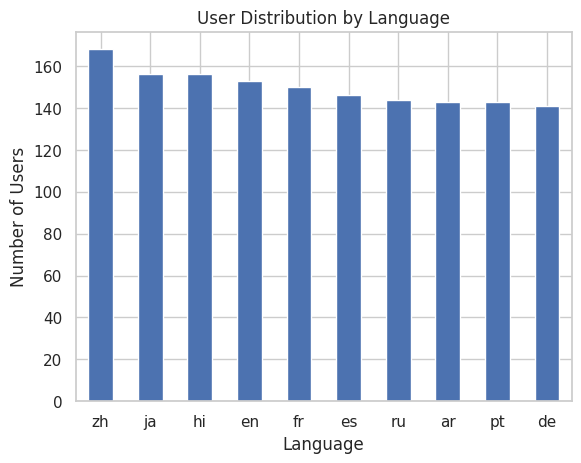

In [15]:
import matplotlib.pyplot as plt

language_counts = users["language"].value_counts()

language_counts.plot(kind="bar")
plt.title("User Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.show()

**Insight:** The language distribution is relatively balanced across the dataset. Chinese (`zh`) has the highest number of users with 168, while German (`de`) has the lowest with 141. No single language dominates the dataset.

### 2.2 Follower Count Distribution

The distribution of follower counts was visualized to understand how followers are spread across users and to identify any noticeable concentration or extreme values.

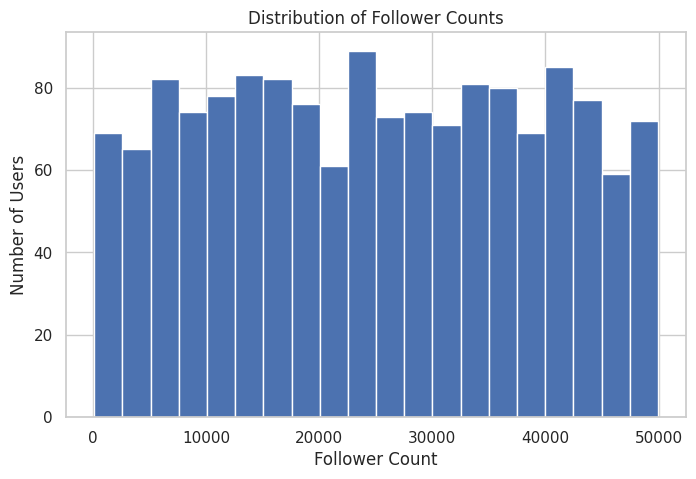

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(users["follower_count"], bins=20)

plt.title("Distribution of Follower Counts")
plt.xlabel("Follower Count")
plt.ylabel("Number of Users")

plt.show()

**Insight:** Follower counts are broadly distributed across the range, with no strong concentration at a particular value. The distribution appears relatively even, indicating that users have varied follower counts.

### 2.3 Account Creation Trend

The number of accounts created over time was analyzed to identify patterns in user registration throughout 2023.

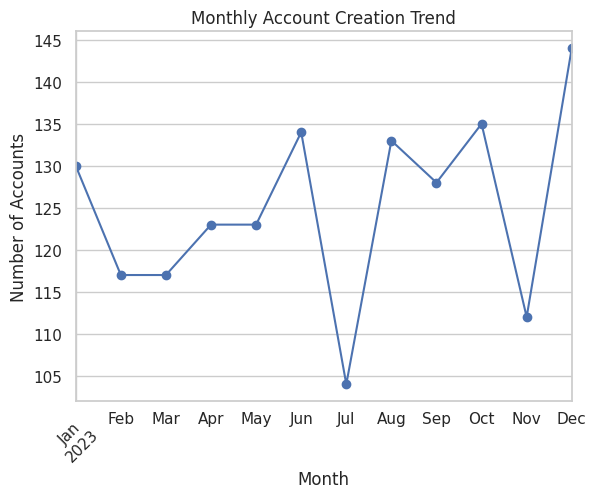

In [17]:
monthly_accounts = users["account_created"].dt.to_period("M").value_counts().sort_index()

monthly_accounts.plot(kind="line", marker="o")

plt.title("Monthly Account Creation Trend")
plt.xlabel("Month")
plt.ylabel("Number of Accounts")
plt.xticks(rotation=45)
plt.show()

**Insight:** Account creation fluctuated throughout 2023, with the lowest number of new accounts in July and the highest in December. There was no consistent upward or downward trend across the year.

### 2.4 Location Distribution

The distribution of users across locations was visualized to identify the locations with the highest and lowest representation in the dataset.

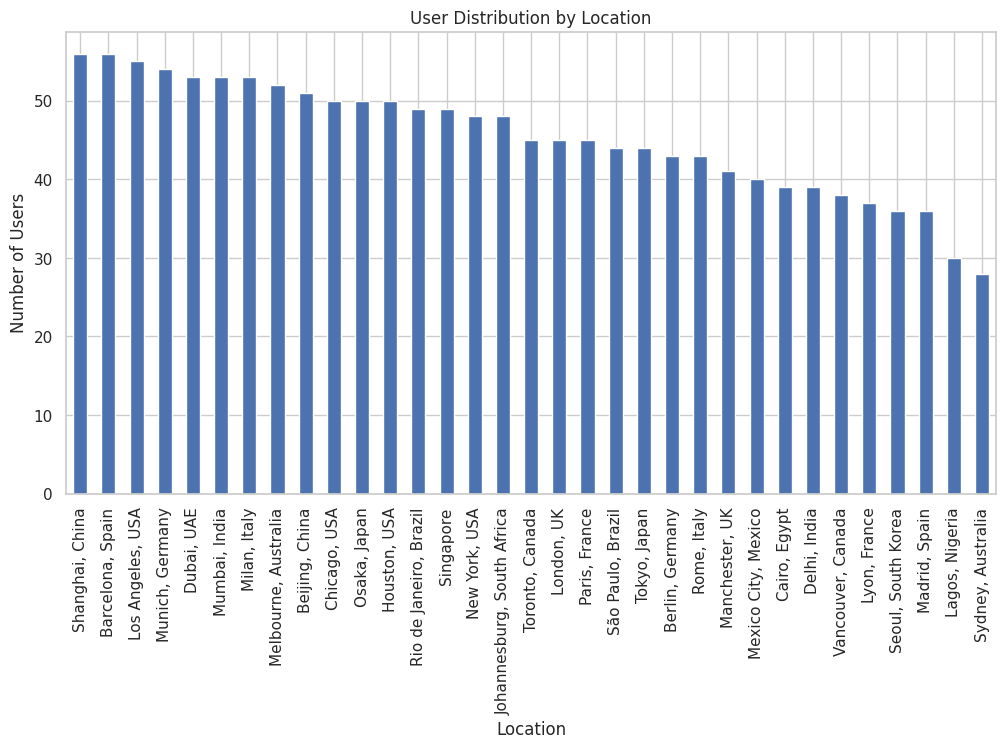

In [18]:
location_counts = users["location"].value_counts()

location_counts.plot(kind="bar", figsize=(12, 6))

plt.title("User Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Number of Users")
plt.xticks(rotation=90)
plt.show()

**Insight:** The users are distributed across 33 different locations, with relatively similar representation across cities. Shanghai and Barcelona have the highest representation with 56 users each, while no single location dominates the dataset.


### 2.5 Follower Count vs Account Creation

The relationship between account creation date and follower count was analyzed to observe whether follower counts show any noticeable pattern over time.

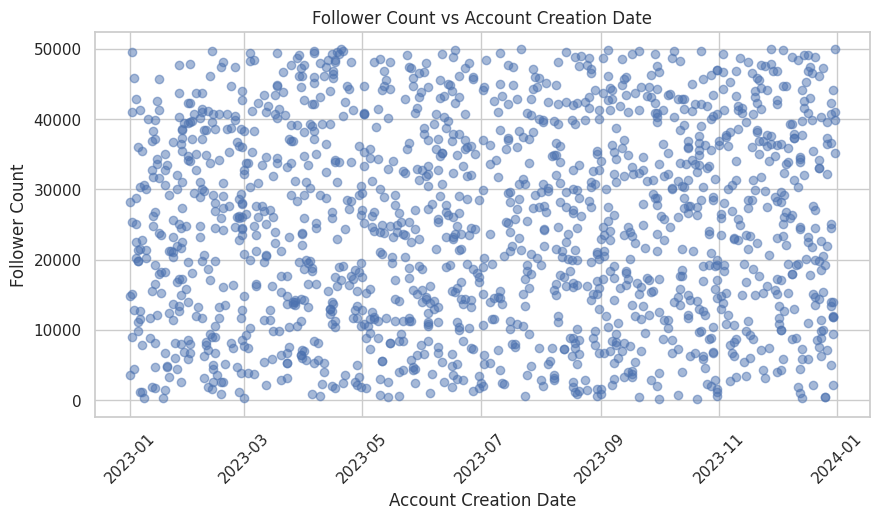

In [19]:
plt.figure(figsize=(10, 5))

plt.scatter(users["account_created"], users["follower_count"], alpha=0.5)

plt.title("Follower Count vs Account Creation Date")
plt.xlabel("Account Creation Date")
plt.ylabel("Follower Count")
plt.xticks(rotation=45)
plt.show()

**Insight:** Follower counts are widely scattered across all account creation dates, with no clear upward or downward pattern. This suggests that account creation date does not show an obvious relationship with follower count in this dataset.

## 3. Key Insights

The exploratory analysis of the cleaned dataset revealed the following key insights:

1. **Language Distribution:** The dataset has a relatively balanced representation across the 10 languages, with Chinese (`zh`) having the highest number of users.

2. **Follower Count:** Follower counts are broadly distributed between 109 and 49,944, with no obvious concentration at a particular value.

3. **Account Creation:** Account registrations fluctuated throughout 2023, with July showing the lowest number of new accounts and December showing the highest.

4. **Location Distribution:** Users are distributed across 33 locations, with relatively similar representation across cities.

5. **Follower Count vs Account Creation:** No clear relationship was observed between account creation date and follower count.


In [22]:
users.to_csv("Social_Engine_Users_Cleaned.csv", index=False)